# Cross-Ticker Latent Analysis Comparison

Compares P5 latent-space explainability findings across all 8 tickers to assess whether the AAPL results generalise.

**Key questions:**
1. Do all tickers show ~3-factor effective dimensionality?
2. Do learned dims universally align with ATM level / term slope / skew?
3. Do rho and theta Heston params always have strong latent correlates?
4. Are there ticker-specific exceptions (VIX, TSLA, F)?

In [1]:
import os, sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

ROOT = Path(os.getcwd())
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

TICKERS  = ["AAPL", "GOOGL", "NVDA", "TSLA", "F", "XOM", "CVX", "VIX"]
VARIANTS = ["mlp", "mlp_log", "mlp_log_arb", "conv", "conv_log", "conv_log_arb"]
LATENT_ROOT = ROOT / "artifacts" / "validation" / "latent_analysis"
OUT_DIR = ROOT / "artifacts" / "comparison" / "cross_ticker_latent"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="tab10")
print(f"Project root : {ROOT}")
print(f"Output dir   : {OUT_DIR}")

Project root : C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis
Output dir   : C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\comparison\cross_ticker_latent


In [2]:
def load_summary(ticker, table_name_template):
    path = LATENT_ROOT / ticker / "tables" / table_name_template.format(ticker=ticker)
    return pd.read_csv(path) if path.exists() else None

# Availability check
for t in TICKERS:
    kl = load_summary(t, "kl_summary_{ticker}.csv")
    fe = load_summary(t, "latent_feature_best_match_{ticker}.csv")
    he = load_summary(t, "heston_latent_best_match_{ticker}.csv")
    pc = load_summary(t, "pca_summary_{ticker}.csv")
    ok = all(x is not None for x in [kl, fe, he, pc])
    print(f"{'OK' if ok else 'MISSING'}  {t}")

OK  AAPL
OK  GOOGL
OK  NVDA
OK  TSLA
OK  F
OK  XOM
OK  CVX
OK  VIX


## 1. KL Concentration — Effective Dimensionality

In [3]:
rows = []
for ticker in TICKERS:
    df = load_summary(ticker, "kl_summary_{ticker}.csv")
    if df is None: continue
    for _, r in df.iterrows():
        rows.append({"Ticker": ticker, "Variant": r["variant"],
                     "top3_share": r["top3_share"],
                     "eff_dims": r["effective_dimensionality_pr"],
                     "dims_to_80": r["dims_to_80pct_kl"]})

kl_df = pd.DataFrame(rows)
summary = kl_df.groupby("Ticker").agg(
    mean_top3_kl=("top3_share","mean"),
    mean_eff_dims=("eff_dims","mean"),
    mean_dims_to_80=("dims_to_80","mean"),
).round(3).reset_index()
summary["mean_top3_kl"] = summary["mean_top3_kl"].map("{:.1%}".format)
summary.columns = ["Ticker","Mean Top-3 KL Share","Mean Eff. Dims (PR)","Mean Dims to 80% KL"]
print("KL Concentration (mean over 6 variants):")
display(summary)
summary.to_csv(OUT_DIR / "kl_concentration_summary.csv", index=False)

KL Concentration (mean over 6 variants):


,Ticker,Mean Top-3 KL Share,Mean Eff. Dims (PR),Mean Dims to 80% KL
0,AAPL,90.5%,3.158,3.000
1,CVX,99.1%,2.185,1.833
2,F,75.5%,4.531,4.000
3,GOOGL,91.4%,3.052,3.000
4,NVDA,87.6%,3.351,2.833
5,TSLA,96.0%,2.558,2.667
6,VIX,76.0%,6.898,5.833
7,XOM,94.4%,1.788,1.833


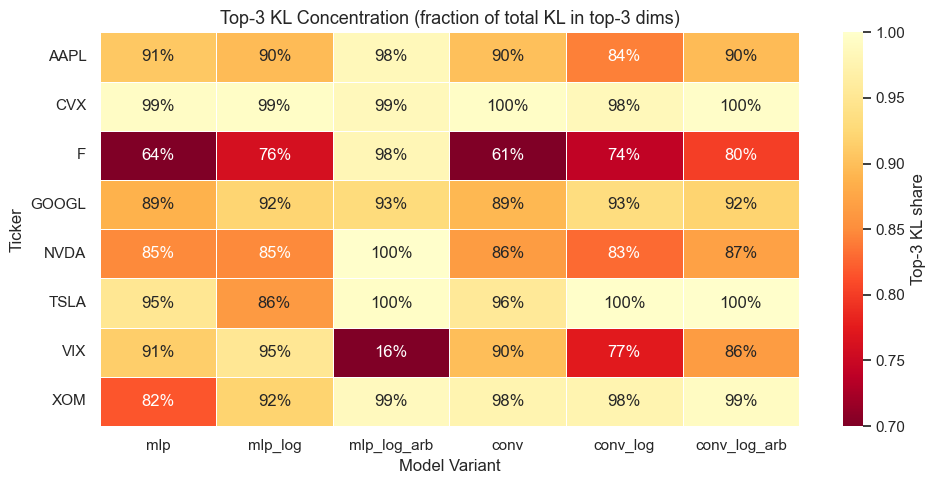

Saved kl_concentration_heatmap.png


In [4]:
kl_pivot = kl_df.pivot_table(index="Ticker", columns="Variant", values="top3_share")
kl_pivot = kl_pivot[VARIANTS]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(kl_pivot, annot=True, fmt=".0%", cmap="YlOrRd_r",
            vmin=0.70, vmax=1.0, ax=ax, linewidths=0.5,
            cbar_kws={"label": "Top-3 KL share"})
ax.set_title("Top-3 KL Concentration (fraction of total KL in top-3 dims)", fontsize=13)
ax.set_xlabel("Model Variant"); ax.set_ylabel("Ticker")
plt.tight_layout()
plt.savefig(OUT_DIR / "kl_concentration_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved kl_concentration_heatmap.png")

## 2. Feature Correlations — Do Latent Dims Map to Financial Factors?

Best |r| between latent dims and market features (max over 6 variants):


Feature,ATM Level,Overall Level,Term Slope,Skew (75-25),Smile Curvature
Ticker,,,,,
AAPL,0.987,0.985,0.869,0.765,0.625
CVX,0.994,0.995,0.872,0.594,0.666
F,0.856,0.977,0.722,0.672,0.796
GOOGL,0.995,0.998,0.917,0.555,0.612
NVDA,0.988,0.992,0.813,0.728,0.601
TSLA,0.998,0.997,0.955,0.739,0.743
VIX,0.963,0.967,0.919,0.526,0.612
XOM,0.992,0.996,0.871,0.770,0.510


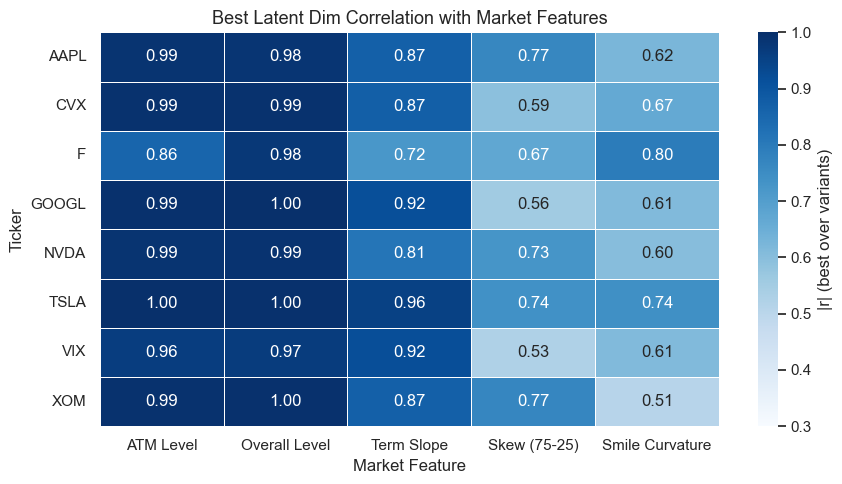

Saved feature_correlation_heatmap.png


In [5]:
KEY_FEATURES = {
    "atm_level_delta50_mean":          "ATM Level",
    "overall_level":                   "Overall Level",
    "term_slope_back_minus_front_atm": "Term Slope",
    "skew_75_minus_25_mean":           "Skew (75-25)",
    "smile_curvature_quad_mean":       "Smile Curvature",
}

feat_rows = []
for ticker in TICKERS:
    df = load_summary(ticker, "latent_feature_best_match_{ticker}.csv")
    if df is None: continue
    for feat_key, feat_label in KEY_FEATURES.items():
        sub = df[df["feature"] == feat_key]
        if sub.empty: continue
        feat_rows.append({"Ticker": ticker, "Feature": feat_label,
                          "best_r": sub["abs_correlation"].max(),
                          "mean_r": sub["abs_correlation"].mean()})

feat_df = pd.DataFrame(feat_rows)
feat_pivot = feat_df.pivot_table(index="Ticker", columns="Feature", values="best_r")
col_order = [v for v in KEY_FEATURES.values() if v in feat_pivot.columns]
feat_pivot = feat_pivot[col_order]

print("Best |r| between latent dims and market features (max over 6 variants):")
display(feat_pivot.round(3))
feat_pivot.to_csv(OUT_DIR / "feature_correlation_best_r.csv")

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(feat_pivot, annot=True, fmt=".2f", cmap="Blues",
            vmin=0.3, vmax=1.0, ax=ax, linewidths=0.5,
            cbar_kws={"label": "|r| (best over variants)"})
ax.set_title("Best Latent Dim Correlation with Market Features", fontsize=13)
ax.set_xlabel("Market Feature"); ax.set_ylabel("Ticker")
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved feature_correlation_heatmap.png")

## 3. Heston Parameter Mapping

Best |r| between latent dims and Heston parameters (max over 6 variants):


Param,rho,theta,v0,kappa,sigma
Ticker,,,,,
AAPL,0.816,0.826,0.222,0.222,0.234
CVX,0.877,0.914,0.392,0.447,0.522
F,0.593,0.369,0.226,0.282,0.254
GOOGL,0.841,0.646,0.396,0.427,0.444
NVDA,0.788,0.771,0.473,0.432,0.491
TSLA,0.881,0.827,0.195,0.252,0.239
VIX,0.580,0.545,0.744,0.627,0.382
XOM,0.860,0.908,0.323,0.297,0.329


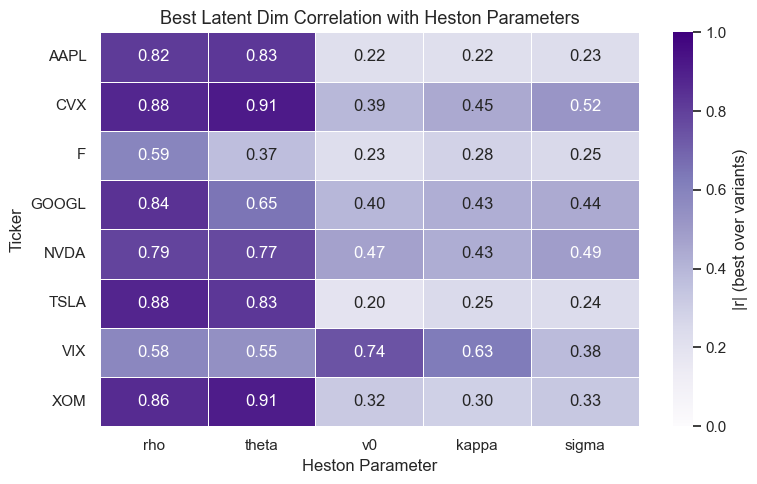

Saved heston_correlation_heatmap.png


In [6]:
KEY_PARAMS = ["rho", "theta", "v0", "kappa", "sigma"]

heston_rows = []
for ticker in TICKERS:
    df = load_summary(ticker, "heston_latent_best_match_{ticker}.csv")
    if df is None: continue
    for param in KEY_PARAMS:
        sub = df[df["heston_param"] == param]
        if sub.empty: continue
        heston_rows.append({"Ticker": ticker, "Param": param,
                            "best_r": sub["abs_correlation"].max(),
                            "mean_r": sub["abs_correlation"].mean()})

heston_df = pd.DataFrame(heston_rows)
heston_pivot = heston_df.pivot_table(index="Ticker", columns="Param", values="best_r")
heston_pivot = heston_pivot[KEY_PARAMS]

print("Best |r| between latent dims and Heston parameters (max over 6 variants):")
display(heston_pivot.round(3))
heston_pivot.to_csv(OUT_DIR / "heston_correlation_best_r.csv")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heston_pivot, annot=True, fmt=".2f", cmap="Purples",
            vmin=0.0, vmax=1.0, ax=ax, linewidths=0.5,
            cbar_kws={"label": "|r| (best over variants)"})
ax.set_title("Best Latent Dim Correlation with Heston Parameters", fontsize=13)
ax.set_xlabel("Heston Parameter"); ax.set_ylabel("Ticker")
plt.tight_layout()
plt.savefig(OUT_DIR / "heston_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved heston_correlation_heatmap.png")

## 4. PCA Concentration — Variance Explained by Top-3 PCs

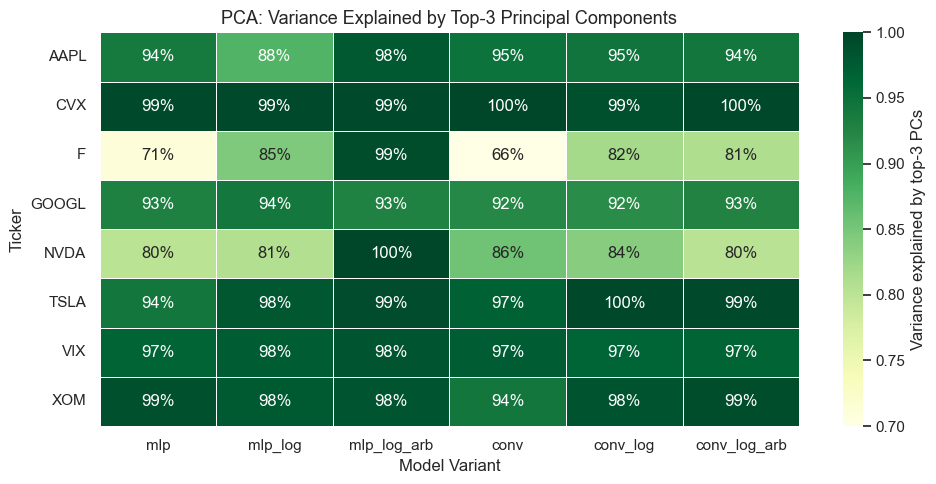

Mean PCA top-3 variance share by ticker:


,Ticker,Mean Top-3 PC Var.
0,AAPL,93.8%
1,CVX,99.4%
2,F,80.6%
3,GOOGL,92.8%
4,NVDA,85.1%
5,TSLA,98.0%
6,VIX,97.2%
7,XOM,97.7%


Saved pca_concentration_heatmap.png + .csv


In [7]:
pca_rows = []
for ticker in TICKERS:
    df = load_summary(ticker, "pca_summary_{ticker}.csv")
    if df is None: continue
    for _, r in df.iterrows():
        pca_rows.append({"Ticker": ticker, "Variant": r["variant"],
                         "top3_pc_var": r["pc1_to_pc3_cumulative_ratio"],
                         "pcs_to_80": r["pcs_to_80pct_variance"]})

pca_df = pd.DataFrame(pca_rows)
pca_pivot = pca_df.pivot_table(index="Ticker", columns="Variant", values="top3_pc_var")
pca_pivot = pca_pivot[VARIANTS]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pca_pivot, annot=True, fmt=".0%", cmap="YlGn",
            vmin=0.70, vmax=1.0, ax=ax, linewidths=0.5,
            cbar_kws={"label": "Variance explained by top-3 PCs"})
ax.set_title("PCA: Variance Explained by Top-3 Principal Components", fontsize=13)
ax.set_xlabel("Model Variant"); ax.set_ylabel("Ticker")
plt.tight_layout()
plt.savefig(OUT_DIR / "pca_concentration_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

pca_ticker_summary = pca_df.groupby("Ticker")["top3_pc_var"].mean().map("{:.1%}".format).reset_index()
pca_ticker_summary.columns = ["Ticker", "Mean Top-3 PC Var."]
print("Mean PCA top-3 variance share by ticker:")
display(pca_ticker_summary)
pca_pivot.to_csv(OUT_DIR / "pca_concentration_heatmap.csv")
print("Saved pca_concentration_heatmap.png + .csv")

## 5. Replication Summary Table

In [8]:
TICKER_TIER = {
    "AAPL":  "Tier 1 (liquid, stable)",
    "GOOGL": "Tier 1 (liquid, stable)",
    "CVX":   "Tier 1 (liquid, stable)",
    "NVDA":  "Tier 2 (high vol)",
    "XOM":   "Tier 2 (high vol)",
    "TSLA":  "Tier 2 (high vol)",
    "F":     "Tier 3 (data quality)",
    "VIX":   "Tier 3 (structural mismatch)",
}

verdict_rows = []
for ticker in TICKERS:
    kl  = load_summary(ticker, "kl_summary_{ticker}.csv")
    fe  = load_summary(ticker, "latent_feature_best_match_{ticker}.csv")
    he  = load_summary(ticker, "heston_latent_best_match_{ticker}.csv")
    pca = load_summary(ticker, "pca_summary_{ticker}.csv")

    top3_kl  = kl["top3_share"].mean()           if kl  is not None else float("nan")
    eff_dims = kl["effective_dimensionality_pr"].mean() if kl is not None else float("nan")
    top3_pca = pca["pc1_to_pc3_cumulative_ratio"].mean() if pca is not None else float("nan")

    def best_feat(df, key):
        if df is None: return float("nan")
        sub = df[df["feature"] == key]
        return sub["abs_correlation"].max() if not sub.empty else float("nan")

    def best_heston(df, param):
        if df is None: return float("nan")
        sub = df[df["heston_param"] == param]
        return sub["abs_correlation"].max() if not sub.empty else float("nan")

    verdict_rows.append({
        "Ticker":          ticker,
        "Tier":            TICKER_TIER.get(ticker, ""),
        "Top-3 KL":        f"{top3_kl:.1%}",
        "Eff. Dims":       f"{eff_dims:.2f}",
        "Top-3 PCA Var.":  f"{top3_pca:.1%}",
        "|r| ATM Level":   f"{best_feat(fe, 'atm_level_delta50_mean'):.3f}",
        "|r| Term Slope":  f"{best_feat(fe, 'term_slope_back_minus_front_atm'):.3f}",
        "|r| Skew":        f"{best_feat(fe, 'skew_75_minus_25_mean'):.3f}",
        "|r| rho":         f"{best_heston(he, 'rho'):.3f}",
        "|r| theta":       f"{best_heston(he, 'theta'):.3f}",
    })

verdict_df = pd.DataFrame(verdict_rows).set_index("Ticker")
print("REPLICATION SUMMARY")
display(verdict_df)
verdict_df.to_csv(OUT_DIR / "replication_summary.csv")
print("Saved replication_summary.csv")

REPLICATION SUMMARY


,Tier,Top-3 KL,Eff. Dims,Top-3 PCA Var.,|r| ATM Level,|r| Term Slope,|r| Skew,|r| rho,|r| theta
Ticker,,,,,,,,,
AAPL,"Tier 1 (liquid, stable)",90.5%,3.16,93.8%,0.987,0.869,0.765,0.816,0.826
GOOGL,"Tier 1 (liquid, stable)",91.4%,3.05,92.8%,0.995,0.917,0.555,0.841,0.646
NVDA,Tier 2 (high vol),87.6%,3.35,85.1%,0.988,0.813,0.728,0.788,0.771
TSLA,Tier 2 (high vol),96.0%,2.56,98.0%,0.998,0.955,0.739,0.881,0.827
F,Tier 3 (data quality),75.5%,4.53,80.6%,0.856,0.722,0.672,0.593,0.369
XOM,Tier 2 (high vol),94.4%,1.79,97.7%,0.992,0.871,0.770,0.860,0.908
CVX,"Tier 1 (liquid, stable)",99.1%,2.18,99.4%,0.994,0.872,0.594,0.877,0.914
VIX,Tier 3 (structural mismatch),76.0%,6.90,97.2%,0.963,0.919,0.526,0.580,0.545


Saved replication_summary.csv


## 6. Interpretation

In [9]:
verdict_df_reset = pd.read_csv(OUT_DIR / "replication_summary.csv")

print("=" * 65)
print("CROSS-TICKER LATENT ANALYSIS — KEY FINDINGS")
print("=" * 65)

print("\n1. KL CONCENTRATION (3-factor finding):")
for _, r in verdict_df_reset.iterrows():
    kl_val = float(r["Top-3 KL"].rstrip("%")) / 100
    ed_val = float(r["Eff. Dims"])
    flag = "STRONG" if kl_val >= 0.80 else "MODERATE" if kl_val >= 0.70 else "WEAK"
    print(f"  {r['Ticker']:6s}: top-3 KL={kl_val:.0%}, eff_dims={ed_val:.2f}  [{flag}]")

print("\n2. ATM LEVEL ALIGNMENT (best |r| over variants):")
for _, r in verdict_df_reset.iterrows():
    v = float(r["|r| ATM Level"])
    flag = "STRONG" if v >= 0.85 else "MODERATE" if v >= 0.70 else "WEAK"
    print(f"  {r['Ticker']:6s}: {v:.3f}  [{flag}]")

print("\n3. HESTON rho ALIGNMENT:")
for _, r in verdict_df_reset.iterrows():
    v = float(r["|r| rho"])
    flag = "STRONG" if v >= 0.65 else "MODERATE" if v >= 0.45 else "WEAK"
    print(f"  {r['Ticker']:6s}: {v:.3f}  [{flag}]")

print("\n4. HESTON theta ALIGNMENT:")
for _, r in verdict_df_reset.iterrows():
    v = float(r["|r| theta"])
    flag = "STRONG" if v >= 0.65 else "MODERATE" if v >= 0.45 else "WEAK"
    print(f"  {r['Ticker']:6s}: {v:.3f}  [{flag}]")

CROSS-TICKER LATENT ANALYSIS — KEY FINDINGS

1. KL CONCENTRATION (3-factor finding):
  AAPL  : top-3 KL=90%, eff_dims=3.16  [STRONG]
  GOOGL : top-3 KL=91%, eff_dims=3.05  [STRONG]
  NVDA  : top-3 KL=88%, eff_dims=3.35  [STRONG]
  TSLA  : top-3 KL=96%, eff_dims=2.56  [STRONG]
  F     : top-3 KL=76%, eff_dims=4.53  [MODERATE]
  XOM   : top-3 KL=94%, eff_dims=1.79  [STRONG]
  CVX   : top-3 KL=99%, eff_dims=2.18  [STRONG]
  VIX   : top-3 KL=76%, eff_dims=6.90  [MODERATE]

2. ATM LEVEL ALIGNMENT (best |r| over variants):
  AAPL  : 0.987  [STRONG]
  GOOGL : 0.995  [STRONG]
  NVDA  : 0.988  [STRONG]
  TSLA  : 0.998  [STRONG]
  F     : 0.856  [STRONG]
  XOM   : 0.992  [STRONG]
  CVX   : 0.994  [STRONG]
  VIX   : 0.963  [STRONG]

3. HESTON rho ALIGNMENT:
  AAPL  : 0.816  [STRONG]
  GOOGL : 0.841  [STRONG]
  NVDA  : 0.788  [STRONG]
  TSLA  : 0.881  [STRONG]
  F     : 0.593  [MODERATE]
  XOM   : 0.860  [STRONG]
  CVX   : 0.877  [STRONG]
  VIX   : 0.580  [MODERATE]

4. HESTON theta ALIGNMENT:
  A